In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from path_config import PathConfig

In [2]:
paths = PathConfig()

In [3]:
data = pd.read_csv(paths._processed_saha_olcum_dir / "5G_DataSet.csv")
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

In [4]:
def latitude_to_meter(df):
    latitude = df["Latitude"]*111320
    return latitude

def longitude_to_meter(df):
    longitude = np.cos(np.radians(df["Latitude"]))*111320*df["Longitude"]
    return longitude

In [5]:
data["x"] = latitude_to_meter(data)
data["y"] = longitude_to_meter(data)

x = data["x"]
y = data["y"]
t = data["Time"]

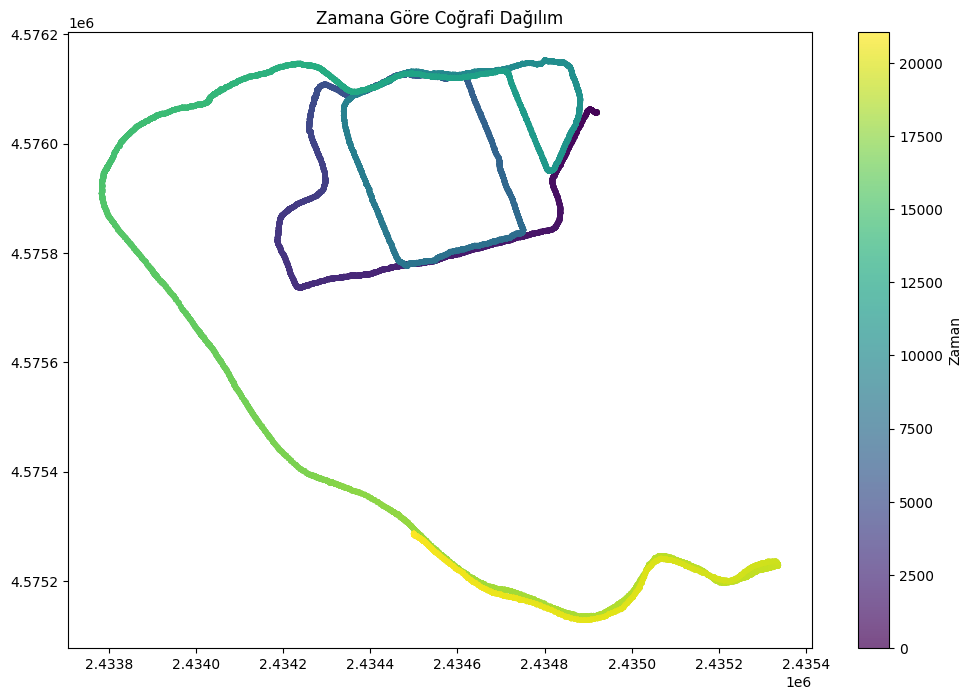

In [6]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    y,
    x,
    c= range(len(t)),
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.colorbar(sc, label="Zaman")
ax.set_title("Zamana Göre Coğrafi Dağılım")
plt.show()

In [7]:
data = data.drop(columns=["Longitude", "Latitude", "Time"])

X = data[["x","y"]]

n=10

kmeans = KMeans(n_clusters=n, random_state=0,n_init="auto").fit(X)
predictions = kmeans.predict(X)
data["Group"] = predictions

cluster_centers = kmeans.cluster_centers_
cluster_centers_x = list(cluster_centers[:,0:1])
cluster_centers_y = list(cluster_centers[:,1:2])

In [8]:
list(set(predictions))

[np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8),
 np.int32(9)]

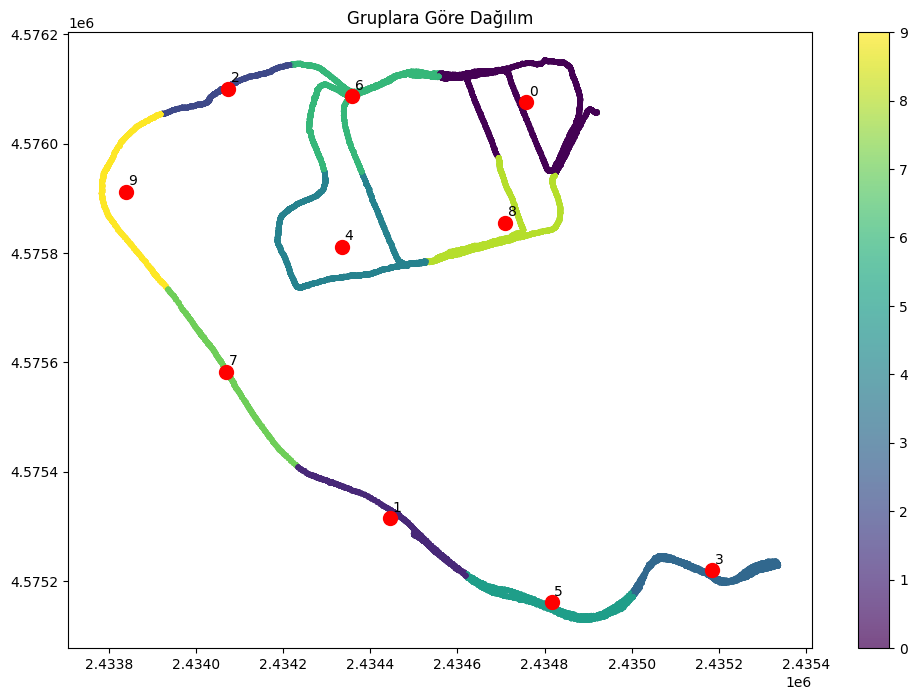

In [9]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    y,
    x,
    c=predictions,
    cmap="viridis",
    s=10,
    alpha=0.7
)

ax.scatter(
    cluster_centers_y,
    cluster_centers_x,
    s=100,
    c="red",
    
)

for i, (x_, y_) in enumerate(zip(cluster_centers_x, cluster_centers_y)):
    ax.annotate(str(i), (y_, x_), textcoords="offset points", xytext=(5, 5), ha='center')
    
ax.set_title("Gruplara Göre Dağılım")

cbar = plt.colorbar(sc)

plt.show()

In [10]:
distance_matrix = np.zeros(shape=(n,n))

for i in range(n):
    for j in range(n):
        if i == j:
            distance_matrix[i:i+1,j:j+1] = 0
        elif j>i:
            distance_matrix[j:j+1,i:i+1] = distance_matrix[i:i+1,j:j+1] = np.sum((cluster_centers[i:i+1]-cluster_centers[j:j+1])**2)**0.5

pd.DataFrame(distance_matrix)

,0,1,2,3,4,5,6,7,8,9
0,0.000000,823.013445,684.735033,956.242435,499.430510,916.116497,400.333270,847.090651,225.380564,933.566375
1,823.013445,0.000000,869.325783,745.625126,509.052829,401.856672,776.635567,462.137203,602.325749,850.794762
2,684.735033,869.325783,0.000000,1417.627778,389.238848,1197.400807,284.449730,517.537268,681.618666,301.334118
3,956.242435,745.625126,1417.627778,0.000000,1035.841688,372.642050,1197.569005,1173.326668,793.421170,1513.038458
4,499.430510,509.052829,389.238848,1035.841688,0.000000,809.344386,275.875349,350.062435,378.110479,505.333758
5,916.116497,401.856672,1197.400807,372.642050,809.344386,0.000000,1032.330156,858.350912,702.251548,1232.278810
6,400.333270,776.635567,284.449730,1197.569005,275.875349,1032.330156,0.000000,580.234224,420.838929,547.435394
7,847.090651,462.137203,517.537268,1173.326668,350.062435,858.350912,580.234224,0.000000,696.396208,401.052114
8,225.380564,602.325749,681.618666,793.421170,378.110479,702.251548,420.838929,696.396208,0.000000,872.615188
9,933.566375,850.794762,301.334118,1513.038458,505.333758,1232.278810,547.435394,401.052114,872.615188,0.000000


In [11]:
def n_combs(list_,n):
    
    if n==0:
        return[[]]
    
    output_list = []

    for i in range(len(list_)):
        m = list_[i]
        remaining_list = list_[i+1:]
        remaining_list_combs = n_combs(remaining_list,n-1)

        for p in remaining_list_combs:
            output_list.append([m,*p])

    return output_list

In [12]:
pair_list = n_combs(range(n),2)
n_pairs = int(n/2)
all_matchings = []

for combo in n_combs(pair_list, n_pairs):
    flat = [i for pair in combo for i in pair]

    if len(set(flat)) == n:
        all_matchings.append(combo)

for i,row in enumerate(all_matchings):
    total_distance = 0
    first_tuple = row[0]
    min_distance = distance_matrix[first_tuple[0],first_tuple[1]]

    for tupl in row:
        distance = distance_matrix[tupl[0],tupl[1]]
        total_distance += distance

        if min_distance > distance:
            min_distance = distance

    all_matchings[i].extend([total_distance,min_distance])

combs_distances_df = pd.DataFrame(all_matchings).rename(columns={n_pairs:"total_distance", n_pairs+1:"min_distance"})

In [13]:
print(combs_distances_df.sort_values(by="total_distance",ascending=False)[:1])
print(combs_distances_df.sort_values(by="min_distance",ascending=False)[:1])

          0       1       2       3       4  total_distance  min_distance
696  [0, 7]  [1, 6]  [2, 5]  [3, 4]  [8, 9]       4729.5839    776.635567
          0       1       2       3       4  total_distance  min_distance
630  [0, 7]  [1, 2]  [3, 4]  [5, 6]  [8, 9]     4657.203466    847.090651


## Baseline Model

In [14]:
x_mean = data["x"].mean()
y_mean = data["y"].mean()

mean_euclidean_dist = (((data["x"]-x_mean)**2 + (data["y"]-y_mean)**2)**(0.5)).mean()
max_euclidean_dist = max(((data["x"]-x_mean)**2 + (data["y"]-y_mean)**2)**(0.5))

In [15]:
mean_euclidean_dist

np.float64(420.09436753211634)

In [16]:
max_euclidean_dist

1030.1432540696592

## Model 1

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

drop_cols = ["Group","x","y"]

for i in range(n_pairs):
    #pair = list(combs_distances_df.sort_values(by="total_distance",ascending=False)[:1][i])[0]
    pair = list(combs_distances_df.sort_values(by="min_distance",ascending=False)[:1][i])[0]

    if len(data[data["Group"]==pair[0]]) > len(data[data["Group"]==pair[1]]):
        train, test = data[data["Group"]==pair[0]], data[data["Group"]==pair[1]]
    else:
        test, train = data[data["Group"]==pair[0]], data[data["Group"]==pair[1]]

    X_train, X_test = train.drop(columns=drop_cols), test.drop(columns=drop_cols)
    y_train, y_test = train[["x","y"]], test[["x","y"]]

    multioutput_regressor = MultiOutputRegressor(AdaBoostRegressor())

    multioutput_regressor.fit(X_train, y_train)

    y_pred = multioutput_regressor.predict(X_test)

    mean_euclidean_error = np.mean(np.sqrt(np.sum((y_test - y_pred)**2, axis=1)))
    print("Avg Euclidean Distance:", mean_euclidean_error)

    max_euclidean_error = np.max(np.sqrt(np.sum((y_test - y_pred)**2, axis=1)))
    print("Max Euclidean Distance:", max_euclidean_error)
    print("\n")

Avg Euclidean Distance: 751.6199249338929
Max Euclidean Distance: 788.1070412680676


Avg Euclidean Distance: 812.3057617616557
Max Euclidean Distance: 921.1745944989966


Avg Euclidean Distance: 943.2846239252465
Max Euclidean Distance: 1060.6659132760842


Avg Euclidean Distance: 1044.8051298698686
Max Euclidean Distance: 1139.4177635370602


Avg Euclidean Distance: 868.1110931098175
Max Euclidean Distance: 920.2682623795763


